## Working with short-circuit calculations in pandapower  

### The objective is to become familiar with the workflow as well as the internal structure of the calculation results.Here is a little example on how to use the short-circuit calculation. First, we create a simple open ring network with 4 buses, that are connected by one transformer and two lines with one open sectioning point. The network is fed by an external grid connection at bus 1:

**The goals for this exercise are:**
1. Load a simple grid model, consisting of:
   - Bus (4 elements)  
   - Load (2 elements)
   - Static generator (sgen) (3 elements)  
   - Generator (gen) (3 elements)  
   - Switch (6 elements)  
   - External grid (ext_grid) (1 element)  
   - Line (3 elements)  

2. Develop a deeper understanding of how short-circuit calculations are performed in pandapower.  

3. Examine the internal structure of short-circuit calculation results.  

4. Run several different fault cases (three-phase, two-phase, and single-phase) and compare the results.

   
**Helpful ressources for this exercise:**

- https://github.com/e2nIEE/pandapower/blob/master/tutorials/shortcircuit/shortcircuit.ipynb
- https://pandapower.readthedocs.io/en/latest/shortcircuit.html
- https://github.com/e2nIEE/pandapower/blob/sce/pandapower/shortcircuit/doc.md



### Importing example network and setting network parameters

In this step, we load grid and adjust several key parameters of the network before running the short-circuit calculation:

- we use pp.from_json(FILENAME.json) to load the net

- **Static generators (sgen):**  
  - The parameter `k` is set to `1.2`, which defines the factor for short-circuit contribution of static generators.  
  - `active_current = False` disables active current injection during the fault.  
  - `in_service = False` temporarily disconnects all static generators from the network.  

- **Generators (gen):**  
  - `current_source = False` switches generators from the ideal current source model to a voltage source model.  
  - `in_service = False` temporarily disconnects all generators from the network.  

- **Line parameters:**  
  - `c0_nf_per_km = 0` and `c_nf_per_km = 0` set the zero-sequence and positive-sequence line capacitances to zero.  
  - This is a common simplification in short-circuit studies, since line capacitances are usually neglected in fault calculations.  

These settings allow us to control the behavior of the grid elements during the fault analysis and to focus only on the relevant contributions to the short-circuit current.

In [1]:
import pandapower as pp
net = pp.from_json("../1_four_bus_radial_grid_gen.json")
net.sgen['k'] = 1.2
net.sgen['active_current'] = False
net.gen['current_source'] = False
net.sgen.in_service = False
net.gen.in_service = False
net.line["c0_nf_per_km"] = 0
net.line["c_nf_per_km"] = 0


### Plotting the grid 

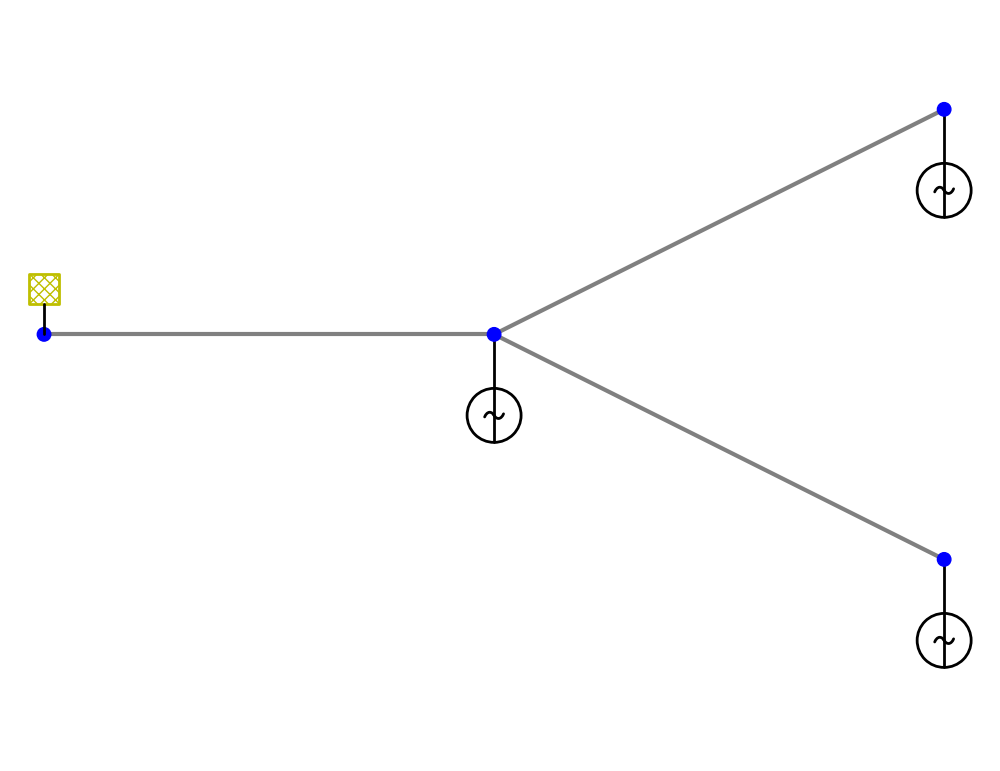

In [2]:
import pandapower.plotting as plot
from pandapower.plotting import simple_plot, create_generic_coordinates, set_line_geodata_from_bus_geodata
def plot(net):
    create_generic_coordinates(net, overwrite=True)
    set_line_geodata_from_bus_geodata(net, overwrite=True)

    simple_plot(
        net,
        line_width=3.,
        plot_loads=False, plot_gens=True, plot_sgens=False,
        load_size=1.5, gen_size=4., sgen_size=5., ext_grid_size=1.5
    )
plot(net)


### Preparing for short-circuit calculation

Before running the short-circuit calculation,
we activate one generator connected to **bus 1**.  
This ensures that the generator is included in the network model during the fault analysis.
This also ensures that the following `calc_sc()` run produces meaningful results.

In [3]:
net.gen.loc[net.gen.bus == 1, 'in_service'] = True

### Running short-circuit calculation


First, we import pandapower's short-circuit module, then we run the short-circuit calculation with:

- fault="3ph" → simulates a three-phase short-circuit at bus 1.
- case="max" → calculates the maximum fault current scenario.
- bus=1 → bus number where the fault is applied.   

In [4]:
from pandapower.shortcircuit.calc_sc import calc_sc

calc_sc(net,fault="3ph",case="max",bus=1,return_all_currents=False,branch_results=True,ip=False,
        r_fault_ohm=0,x_fault_ohm=0, lv_tol_percent=6)

Branch results are in beta mode and might not always be reliable, especially for transformers


### Step 6  — explaining short-circuit calculations 

If we press **Ctrl + click** on `calc_sc` in Jupyter or an IDE, we are taken to the file **`calc_sc.py`**, where the function is defined.  
There we can see the full function signature and all available parameters that control the short-circuit calculation.

```python
def calc_sc(net, bus=None,
            fault="3ph", case='max', lv_tol_percent=10, topology="auto", ip=False,
            ith=False, tk_s=1., kappa_method="C", r_fault_ohm=0., x_fault_ohm=0.,
            branch_results=False, check_connectivity=True, return_all_currents=False,
            inverse_y=True, use_pre_fault_voltage=False)


            
```
A complete list of parameters with explanationscan be found in the [pandapower short-circuit documentation](https://pandapower.readthedocs.io/en/latest/shortcircuit.html).  

In [5]:
net.ext_grid

,name,bus,vm_pu,va_degree,slack_weight,in_service,controllable,s_sc_max_mva,s_sc_min_mva,rx_min,rx_max,r0x0_max,x0x_max,r0x0_min,x0x_min,description,equipment
0,External Grid,0,1.0,0.0,1.0,True,False,100.0,80.0,0.1,0.1,0.1,1.0,0.1,1.0,,


### How the Calculations Are Performed

If we look deeper into the `calc_sc` function, we can observe two important stages:

1. **Fault selection** — the function first checks the selected fault type (three-phase, two-phase, or single-phase) and prepares the calculation accordingly.
   
    ```python
    if fault in ["3ph", "2ph", "1ph", "2ph-g"]:
        msg = ("Short-circuit fault types 3ph, 2ph, 2ph-g and 1ph have been renamed to LLL, LL, LLG and LG, "
            "please use the new naming convention as the old convention will be removed in future pandapower versions.")
        warnings.warn(msg, DeprecationWarning)
        mapping = {"3ph": "LLL", "2ph": "LL", "1ph": "LG", "2ph-g": "LLG"}
        fault = mapping[fault]
    ```

   
2. **Computation** — the function then calls the internal routine `_calc_sc_to_g`, which performs the actual short-circuit current calculations.

     ```python
         if fault in ("LLL", "LG", "LLG", "LL"):
            _calc_sc_to_g(net, bus)
        else:
            raise ValueError("Invalid fault %s" % fault)
    ```

This separation makes it easier to understand how pandapower structures its short-circuit analysis: one part handles setup and validation, while the other executes the numerical computation.
 

 

### Inside `_calc_sc_to_g`

The function `_calc_sc_to_g` performs the **core short-circuit current calculation**.  
To understand it better, we can divide the process into six main stages:

1. **Initialization of sequence networks**  
   Positive, negative, and zero-sequence equivalent networks are set up.  

   In short-circuit analysis, a fault is represented using three symmetrical components - **Method of Symmetrical Components**. 

    - **Positive-sequence network** → represents the normal balanced system (rotating in the correct direction).


      ```python
  
        ppc_1, ppci_1 = _init_ppc(net)

    
      ```
  
  
    - **Negative-sequence network** → represents a "mirror image" imbalance (rotating in the opposite direction).  

    
      ```python
      
        ppc_2, ppci_2 = _init_ppc(net, sequence=2)
    
    
      ```
  
    - **Zero-sequence network** → represents currents that flow equally in all three phases and return through ground or neutral.


      ```python
  
        ppc_0, ppci_0 = _pd2ppc_zero(net, ppc_1['branch'][:, K_ST])
    



      ```  

  
      By combining these three sequence networks in different ways, we can model any type of fault (3-phase, line-to-line, line-to-ground, etc.). 
      Any unbalanced three-phase system of phasors (currents or voltages) can be represented as the sum of three balanced systems of phasors, known as symmetrical components.


   

2. **Building Ybus and Zbus**
     To perform the fault calculation, pandapower first constructs the **admittance matrix (Ybus)** for each sequence network.
   
   - **Ybus (Admittance Matrix)** → describes how buses are interconnected by lines, transformers, and other elements. It relates bus voltages to injected currents. Think   of it as a "map" of how easy it is for current to flow between buses.
     
      ```python
      
        _calc_ybus(ppci_1)

        _calc_ybus(ppci_2)

        _calc_ybus(ppci_0)
        
    
      ```
    
   - **Zbus (Impedance Matrix)** → the inverse of Ybus. It describes how voltages change when a current is injected at a bus. In fault analysis, Zbus makes it possible to directly      calculate fault currents at any bus.
   
      ```python
      
        _calc_zbus(net, ppci_0)
        
        _calc_zbus(net, ppci_1)
        
        _calc_zbus(net, ppci_2)
        
      ``` 

    - In the `_calc_sc_to_g` function:  
        - `_calc_ybus` builds the admittance matrices for the positive, negative, and zero-sequence systems.  
        - `_calc_zbus` (if enabled) computes the impedance matrices used to determine the short-circuit current at the faulted bus.

       
      ```python
            if net["_options"]["inverse_y"]:
                _calc_zbus(net, ppci_0)
                _calc_zbus(net, ppci_1)
                _calc_zbus(net, ppci_2)
            else:
                # Factorization Ybus once
                ppci_0["internal"]["ybus_fact"] = factorized(ppci_0["internal"]["Ybus"].tocsc())
                ppci_1["internal"]["ybus_fact"] = factorized(ppci_1["internal"]["Ybus"].tocsc())
                ppci_2["internal"]["ybus_fact"] = factorized(ppci_2["internal"]["Ybus"].tocsc())

    
      ```
     
4. **Calcualtion of equivalent short-circuit impedance**

    `_calc_rx` determines the effective impedance "seen" by the fault at the chosen bus for positive, negative, and zero-sequence networks. This step is crucial because the fault        current is later computed as voltage / impedance.
    
   ```python
   
        _calc_rx(net, ppci_1, ppci_bus, 1)
        _calc_rx(net, ppci_0, ppci_bus, 0)
        _calc_rx(net, ppci_2, ppci_bus, 2)
            
    ```
             
     If we **Ctrl + click** into `_calc_rx` (in `impedance.py`), there we can see that it calculates the equivalent Thevenin impedance at the faulted bus. It considers any user-       defined fault impedance (R_fault, X_fault), extracts the self-impedance from the Zbus matrix, makes adjustments in case of line-to-line faults, and then stores the results in      `ppci["bus"]` for the positive, negative, and zero-sequence networks.


5. **Fault Current Calculation -`_calc_ikss_to_g`**

     Now  `_calc_ikss_to_g` function is called in order to calculate short-circuit current.

     ```python
     
    ppc_0, ppci_0 = _pd2ppc_zero(net, ppc_1['branch'][:, K_ST])
    
      ```  


    If we **Ctrl + click** into `_calc_ikss_to_g`, we can see that it is the main procedure  for calculating the initial short-circuit current (Ikss).It also computes the initial short-circuit power (Skss), and         post-fault voltages for different fault types at selected buses in a power system. It sets up base currents and sequence impedances (zero, positive, negative), determines prefault or limit-based voltages, and       then  calculates fault currents depending on the fault type: LLL (three-phase) uses only positive-sequence; LG (single line-to-ground) uses all three sequences (0, 1, 2); LLG (double line-to-ground) combines        all sequences with shared contributions; and LL (line-to-line) uses positive - and negative-sequence with opposite signs. The results are normalized to base values, angles are computed, short-circuit powers are     derived, and all values are stored back in the system model for further analysis.

   

7. **Fault and branch current calculation**

    After `_calc_ikss_to_g` finishes calculating the short-circuit currents and powers at the buses, this final block in `calc_sc` handles the post-processing of results. 

    - If branch results are requested, it calls `_calc_branch_currents_complex` for each sequence (0, 1, 2) to compute the fault currents flowing through lines and transformers.  
    - Then, the results from the internal `ppci` structures are copied into the user-facing `ppc` structures with `_copy_results_ppci_to_ppc`, ensuring all sequence data is              stored.  
    - Finally, `_extract_results` gathers the bus and branch short-circuit values into the `net` object, and `_clean_up` removes temporary data, leaving the short-circuit                calculation complete and ready for reporting.

        ```python
           if net._options["branch_results"]:
              _calc_branch_currents_complex(net, ppci_bus, ppci_0, ppci_1, ppci_2, 0)
              _calc_branch_currents_complex(net, ppci_bus, ppci_0, ppci_1, ppci_2, 1)
              _calc_branch_currents_complex(net, ppci_bus, ppci_0, ppci_1, ppci_2, 2)

           ppc_0 = _copy_results_ppci_to_ppc(ppci_0, ppc_0, "sc")
           ppc_1 = _copy_results_ppci_to_ppc(ppci_1, ppc_1, "sc")
           ppc_2 = _copy_results_ppci_to_ppc(ppci_2, ppc_2, "sc")
           _extract_results(net, ppc_0, ppc_1, ppc_2, bus=bus)
           _clean_up(net)


           
        ```


   A comprehensive glossary of parameters and detailed explanations(calculation methods, code structure etc.) can be found in the                                                     [pandapower short-circuit documentation](https://github.com/e2nIEE/pandapower/blob/sce/pandapower/shortcircuit/doc.md).

## Code and function structure

The short-circuit module in pandapower systematically computes network impedances and fault currents through a modular set of scripts
    
 Main script: calc_sc.py – orchestrates short-circuit analysis
    
       
<img src="code_fun_structure.png" width="46%">
    
       
Key components:
        
 - currents.py → calculates short-circuit currents
        
 - impedance.py → computes network impedances using current data
        
 - kappa.py → calculates correction factors; provides data to impedance.py
        
 - ppc_conversion.py → converts network to PPC format for calculations
        
 - results.py → formats and collects calculation outcomes
        
 - toolbox.py → utility functions supporting calculations
        
  Each component works together to provide precise and easily interpretable results.
  
  A comprehensive glossary of parameters and detailed explanations(calculation methods, code structure etc.) can be found in the                                                     [pandapower short-circuit documentation](https://github.com/e2nIEE/pandapower/blob/sce/pandapower/shortcircuit/doc.md).
  

### Bus short-circuit calculations results

In [6]:
print("Short-circuit results at buses for fault type: %s" % net["_options"]["fault"])
display(net.res_bus_sc)

Short-circuit results at buses for fault type: 3ph


,ikss_ka,skss_mw,rk_ohm,xk_ohm
1,3.330151,115.359798,0.815131,3.726034


### Line short-circuit calculations results

In [7]:
print("Short-circuit results at lines for fault type: %s" % net["_options"]["fault"])
display(net.res_line_sc)

Short-circuit results at lines for fault type: 3ph


,ikss_ka,ikss_from_ka,ikss_from_degree,ikss_to_ka,ikss_to_degree,p_from_mw,q_from_mvar,p_to_mw,q_to_mvar,vm_from_pu,va_from_degree,vm_to_pu,va_to_degree
0,2.510392,2.510392,-79.087781,2.510392,100.912219,9.831226,11.15466,0.0,-0.0,0.170979,-30.479312,0.0,0.0
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.000000,0.000000,0.0,0.0
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.000000,0.000000,0.0,0.0
